In [14]:
import pandas as pd
import numpy as np
import seaborn as sns

from scipy import interpolate

In [15]:
x_col = "#timestamp [ns]"
cols_to_interpolate = ['w_RS_S_x [rad s^-1]', 'w_RS_S_y [rad s^-1]', 'w_RS_S_z [rad s^-1]', 'a_RS_S_x [m s^-2]', 'a_RS_S_y [m s^-2]', 'a_RS_S_z [m s^-2]']

In [16]:
working_dir = '/home/shiva/Datasets/V2_01_easy/V2_01_easy'

In [17]:
df_interp_error = pd.read_csv(working_dir + '/mav0_euroc/imu0/data_modified_0.1ms_jitter.csv')
df_error_cpy = df_interp_error.copy(deep=True)

In [18]:
df_orig = pd.read_csv(working_dir + '/mav0_euroc/imu0/data.csv')

In [19]:
pd.set_option('display.precision', 25)

In [20]:
df_orig.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22800 entries, 0 to 22799
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   #timestamp [ns]      22800 non-null  int64  
 1   w_RS_S_x [rad s^-1]  22800 non-null  float64
 2   w_RS_S_y [rad s^-1]  22800 non-null  float64
 3   w_RS_S_z [rad s^-1]  22800 non-null  float64
 4   a_RS_S_x [m s^-2]    22800 non-null  float64
 5   a_RS_S_y [m s^-2]    22800 non-null  float64
 6   a_RS_S_z [m s^-2]    22800 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 1.2 MB


In [21]:
df_error_cpy.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22800 entries, 0 to 22799
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   #timestamp [ns]      22800 non-null  int64  
 1   w_RS_S_x [rad s^-1]  22800 non-null  float64
 2   w_RS_S_y [rad s^-1]  22800 non-null  float64
 3   w_RS_S_z [rad s^-1]  22800 non-null  float64
 4   a_RS_S_x [m s^-2]    22800 non-null  float64
 5   a_RS_S_y [m s^-2]    22800 non-null  float64
 6   a_RS_S_z [m s^-2]    22800 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 1.2 MB


<Axes: xlabel='#timestamp [ns]', ylabel='w_RS_S_x [rad s^-1]'>

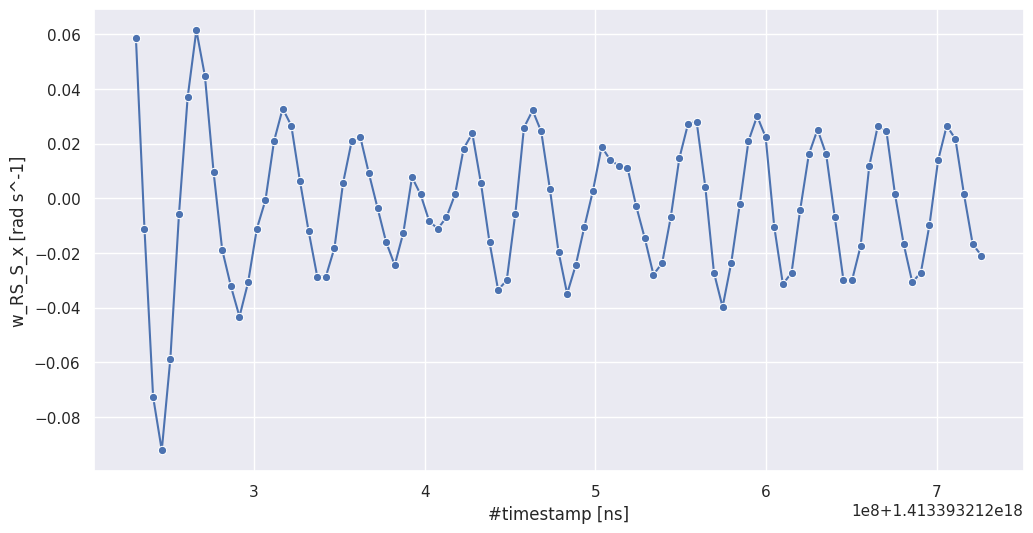

In [22]:
sns.lineplot(data=df_error_cpy.iloc[1:100], x='#timestamp [ns]', y='w_RS_S_x [rad s^-1]', marker='o')

<Axes: xlabel='position', ylabel='delta'>

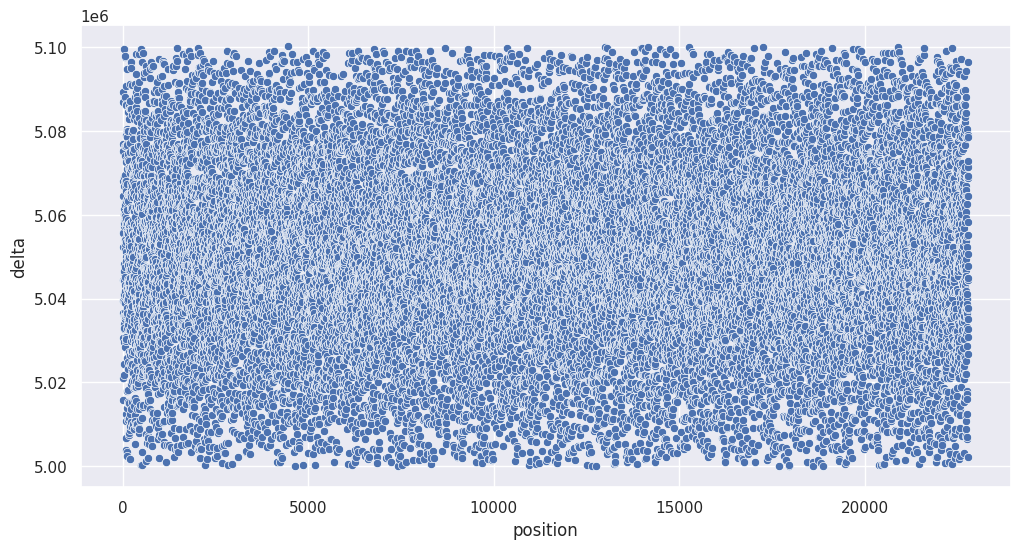

In [23]:
deltas = np.diff(df_interp_error[x_col])
delta_df = pd.DataFrame({'position': np.arange(0, len(deltas)) , 'delta':deltas})
sns.set_theme(rc={'figure.figsize':(12, 6)})
sns.scatterplot(data=delta_df, x='position', y='delta')

In [24]:
def interpolate_data_v3(df: pd.DataFrame,
                        x_col: str,
                        y_col: str,
                        orig_timestamps: np.array) -> np.array:
    interpolated_values = []
    interpolated_values.append(df[y_col].values[0])
    interp_fn = interpolate.interp1d(df[x_col].values, df[y_col].values, kind='linear')
    for orig_timestamp in orig_timestamps[1:]:
        interpolated_values.append(interp_fn(orig_timestamp))
    return interpolated_values

In [25]:
def interpolate_data_v2(df: pd.DataFrame,
                        x_col: str,
                        y_col: str,
                        orig_timestamps: np.array) -> np.array:
    interpolated_values = []
    interpolated_values.append(df[y_col].values[0])
    for orig_timestamp in orig_timestamps[1:]:
        # print("Looking for: ", orig_timestamp)
        lower_bound_idx = df[df['#timestamp [ns]'] <= orig_timestamp].index.max()
        upper_bound_idx = df[df['#timestamp [ns]'] > orig_timestamp].index.min()
        # print(f"Found between indicies {lower_bound_idx} and {upper_bound_idx}.")
        bounds_df = df.iloc[lower_bound_idx: upper_bound_idx+1]
        # print(bounds_df)
        interp_fn = interpolate.interp1d(bounds_df[x_col].values, bounds_df[y_col].values, kind='linear')
        # print(interp_fn(orig_timestamp))
        interpolated_values.append(interp_fn(orig_timestamp))
        # break
    return interpolated_values

In [26]:
for index, col_to_interpolate in enumerate(cols_to_interpolate):
    print(f"Performing interpolation for - {col_to_interpolate}")
    for index in range(0, df_orig.shape[0]):
        interpolated_values = interpolate_data_v2(df_interp_error, x_col, col_to_interpolate, df_orig[x_col])
        # df_interp_error.loc[index: index+chunk_size-1, col_to_interpolate] = interpolated_data
        df_interp_error[col_to_interpolate] = np.array(interpolated_values)
    break

Performing interpolation for - w_RS_S_x [rad s^-1]


KeyboardInterrupt: 

In [ ]:
df_interp_error[x_col] = df_orig[x_col]

In [ ]:
deltas = np.diff(df_error_cpy[x_col])
delta_df = pd.DataFrame({'position': np.arange(0, len(deltas)) , 'delta':deltas})
sns.set_theme(rc={'figure.figsize':(12, 6)})
sns.scatterplot(data=delta_df, x='position', y='delta')

In [ ]:
deltas = np.diff(df_interp_error[x_col])
delta_df = pd.DataFrame({'position': np.arange(0, len(deltas)) , 'delta':deltas})
sns.set_theme(rc={'figure.figsize':(12, 6)})
sns.scatterplot(data=delta_df, x='position', y='delta')

In [ ]:
df_interp_error.info(verbose=True)

In [ ]:
df_orig['#timestamp [ns]'] = df_orig['#timestamp [ns]']  1413393212225760512

In [190]:
df_error_cpy['#timestamp [ns]'] = df_error_cpy['#timestamp [ns]'] - 1413393212225760512

In [194]:
df_interp_error['#timestamp [ns]'] = df_interp_error['#timestamp [ns]'] - 1413393212225760512

In [191]:
df_orig.head(5)

,#timestamp [ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2],type
0,0,0.0949459113084915040658984,0.0202458193231342016560337,0.0586430628670093975762789,9.1283567083333316816151637,0.1062387083333333065437998,-2.6069344583333329268270973,orig
1,4999936,0.0586430628670093975762789,0.0356047167406843001469241,0.0516617458590320974276544,9.4225562083333311846899960,1.1604535833333331495964558,-2.6232788750000000099760200,orig
2,9999872,-0.0111701072127636993197575,0.0279252680319092005944981,0.0698131700797730986307599,9.3980395833333307820112168,1.6180972499999999314468369,-2.7050009583333327611853747,orig
3,15000064,-0.0726056968829641019569365,0.0335103216382911031634428,0.0698131700797730986307599,9.4961060833333306163694942,0.6701210833333332006489513,-2.8194118750000001227817847,orig
4,20000000,-0.0921533845053005978842364,0.0363028484414820024062109,0.0788888821901436027017596,8.9894291666666656936968138,-0.1307553333333333067667326,-2.7131731666666665248044410,orig


In [198]:
y2 = 0.0586430628670093975762789	
y1 = 0.0949459113084915040658984

x2 = 5030656
x1 = 0

In [199]:
y1 + ((4999936 - x1) * ((y2-y1)/(x2-x1)))

0.05886474836967989

In [192]:
df_error_cpy.head(5)

,#timestamp [ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2],type
0,0,0.0949459113084915040658984,0.0202458193231342016560337,0.0586430628670093975762789,9.1283567083333316816151637,0.1062387083333333065437998,-2.6069344583333329268270973,error
1,5030656,0.0586430628670093975762789,0.0356047167406843001469241,0.0516617458590320974276544,9.4225562083333311846899960,1.1604535833333331495964558,-2.6232788750000000099760200,error
2,10046464,-0.0111701072127636993197575,0.0279252680319092005944981,0.0698131700797730986307599,9.3980395833333307820112168,1.6180972499999999314468369,-2.7050009583333327611853747,error
3,15098880,-0.0726056968829641019569365,0.0335103216382911031634428,0.0698131700797730986307599,9.4961060833333306163694942,0.6701210833333332006489513,-2.8194118750000001227817847,error
4,20175872,-0.0921533845053005978842364,0.0363028484414820024062109,0.0788888821901436027017596,8.9894291666666656936968138,-0.1307553333333333067667326,-2.7131731666666665248044410,error


In [195]:
df_interp_error.head(5)

,#timestamp [ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2],type
0,0,0.0949459113084915040658984,0.0202458193231342016560337,0.0586430628670093975762789,9.1283567083333316816151637,0.1062387083333333065437998,-2.6069344583333329268270973,error_with_interpolation
1,4999936,0.0588647483696798923258342,0.0355109267203237086163448,0.0517043776864687318339797,9.4207596615927080563324125,1.1540159575127642010983209,-2.6231790668477432681982009,error_with_interpolation
2,9999872,-0.0105216104560384091093361,0.0279966026751489842350207,0.0696445609230245260556913,9.3982673190425121134694564,1.6138461834286053075970813,-2.7042418393027265466344033,error_with_interpolation
3,15000064,-0.0714041293103710034140263,0.0334010882226008221085323,0.0698131700797730986307599,9.4941880822692858998834708,0.6886617602857720843445577,-2.8171742070919472133994077,error_with_interpolation
4,20000000,-0.0914762333659023957332934,0.0362061125644251163846477,0.0785744905897087231316789,9.0069809537657974374269543,-0.1030121859830912534050640,-2.7168533800906784492212864,error_with_interpolation


In [203]:
start = 0
stop = 100

In [204]:
# df_error_cpy['type'] = 'error'
df_interp_error['type'] = 'error_with_interpolation'
df_orig['type'] = 'orig'
df_error_cpy['type'] = 'error'

df_merged = pd.concat([ #df_orig.iloc[start:stop], 
                       df_interp_error.iloc[start:stop],
                      df_error_cpy.iloc[start:stop]])

- Why is it that after interpolation, we have an even greater shift??

<Axes: xlabel='#timestamp [ns]', ylabel='w_RS_S_x [rad s^-1]'>

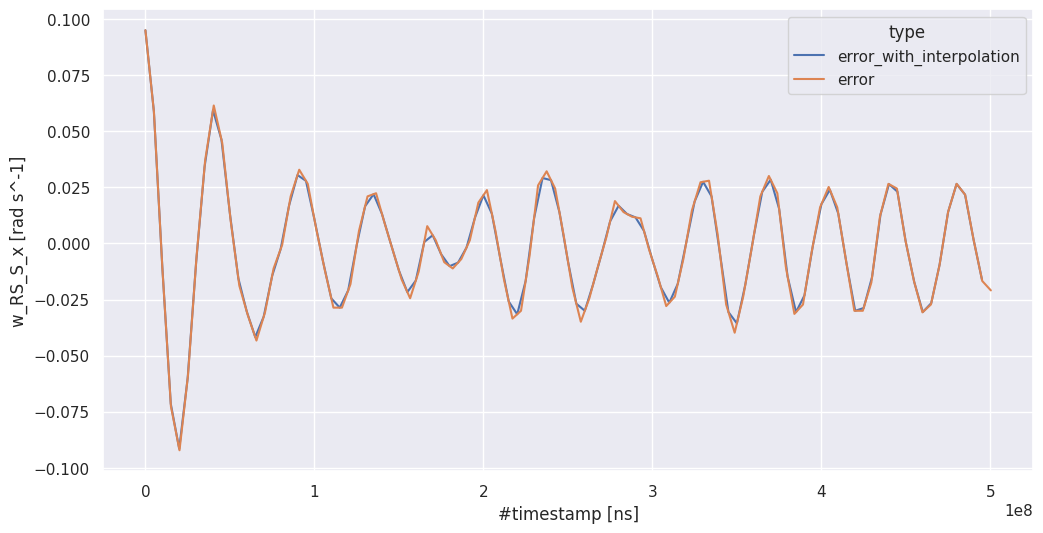

In [205]:
sns.lineplot(data=df_merged, x='#timestamp [ns]', y='w_RS_S_x [rad s^-1]', hue='type')

<Axes: xlabel='#timestamp [ns]', ylabel='a_RS_S_y [m s^-2]'>

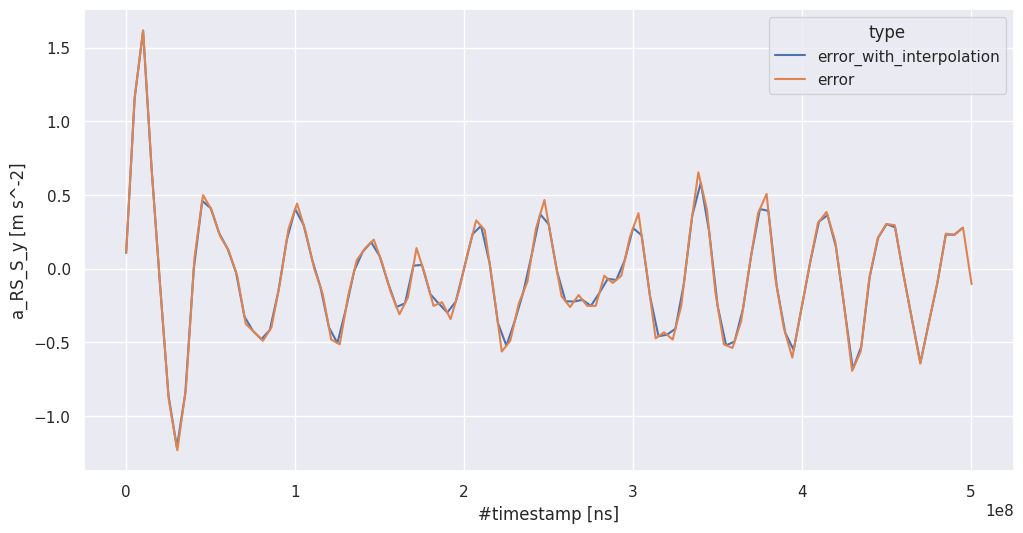

In [206]:
sns.lineplot(data=df_merged, x='#timestamp [ns]', y='a_RS_S_y [m s^-2]', hue='type')

In [227]:
df_orig.iloc[start:stop][["#timestamp [ns]", "w_RS_S_x [rad s^-1]"]].to_csv('orig_x.csv', index=False)

In [228]:
df_error_cpy.iloc[start:stop][["#timestamp [ns]", "w_RS_S_x [rad s^-1]"]].to_csv('error_x.csv', index=False)

In [229]:
df_interp_error.iloc[start:stop][["#timestamp [ns]", "w_RS_S_x [rad s^-1]"]].to_csv('error_interpolated_x.csv', index=False)

In [43]:
filename = 'data_error_interpolated.csv'

In [37]:
df_interp_error.to_csv(working_dir + f'/mav0_euroc/imu0/{filename}', index=False)

In [38]:
!mv {working_dir}/mav0/imu0/data.csv {working_dir}/mav0/imu0/data_old.csv

In [39]:
!cp {working_dir}/mav0_euroc/imu0/{filename} {working_dir}/mav0/imu0/data.csv